=== Video Inspection Details ===
Resolution:    1920 x 1080 pixels
Frame Rate:    30.00 FPS
Total Frames:  4452
Duration:      148.40 seconds
Aspect Ratio:  1.78


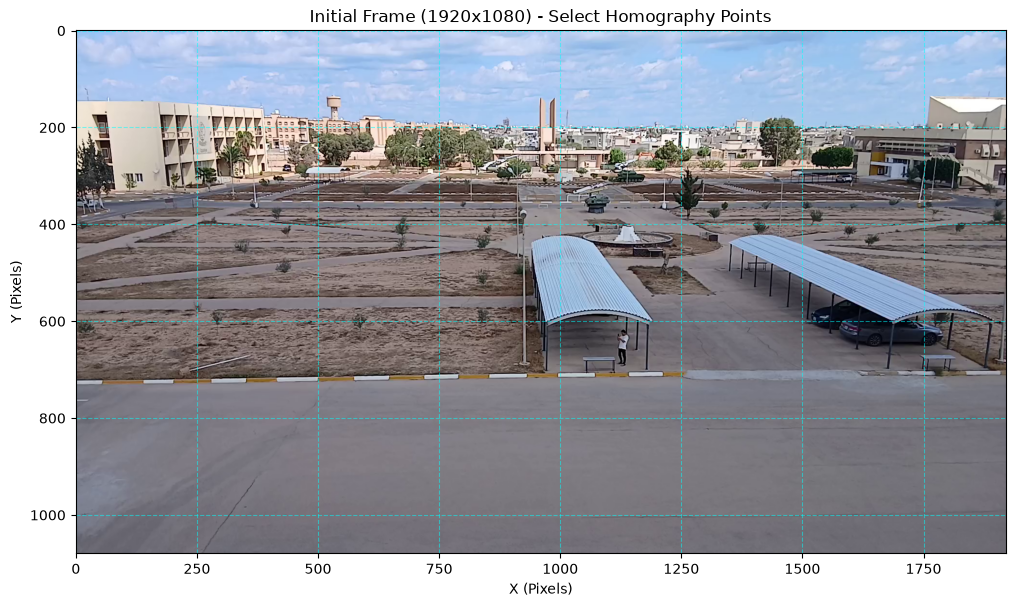

In [2]:
import cv2
import matplotlib.pyplot as plt

# Replace with your phone video file path
VIDEO_PATH = r"C:\Users\PC-LAB1\img_processing_lab\videos\Bera\Bera3.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video file: {VIDEO_PATH}")

# Extract basic video parameters
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration_sec = total_frames / fps if fps > 0 else 0

print("=== Video Inspection Details ===")
print(f"Resolution:    {width} x {height} pixels")
print(f"Frame Rate:    {fps:.2f} FPS")
print(f"Total Frames:  {total_frames}")
print(f"Duration:      {duration_sec:.2f} seconds")
print(f"Aspect Ratio:  {width/height:.2f}")

# Read the first frame
ret, frame = cap.read()
cap.release()

if ret:
    # Render with grid overlay for initial point selection
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Initial Frame ({width}x{height}) - Select Homography Points")
    plt.xlabel("X (Pixels)")
    plt.ylabel("Y (Pixels)")
    plt.grid(True, color='cyan', linestyle='--', alpha=0.5)
    plt.show()
else:
    print("Error: Could not read the first frame.")

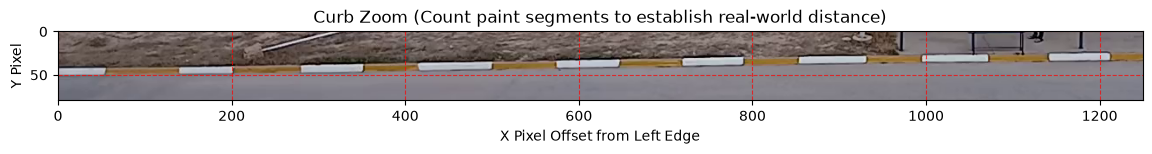

In [3]:
import cv2
import matplotlib.pyplot as plt

# Load the calibration frame
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()

if ret:
    # Zoom in on the curb line (X: 0 to 1250, Y: 680 to 760)
    curb_crop = frame[680:760, 0:1250]
    
    plt.figure(figsize=(14, 4))
    plt.imshow(cv2.cvtColor(curb_crop, cv2.COLOR_BGR2RGB))
    plt.title("Curb Zoom (Count paint segments to establish real-world distance)")
    plt.xlabel("X Pixel Offset from Left Edge")
    plt.ylabel("Y Pixel")
    plt.grid(True, color='red', linestyle='--', alpha=0.7)
    plt.show()

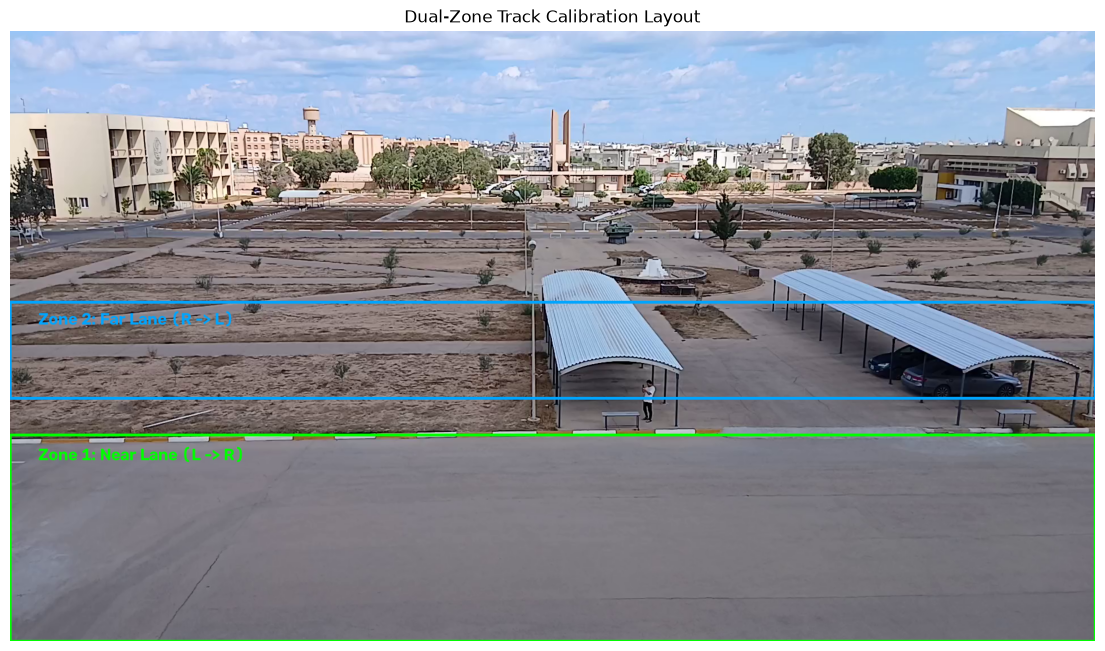

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load main frame
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()

# 1. Define Zone 1 Polygon (Foreground / Near Road)
# Top-Left, Top-Right, Bottom-Right, Bottom-Left
zone1_pts = np.array([
    [0, 715],
    [1920, 715],
    [1920, 1080],
    [0, 1080]
], dtype=np.int32)

# 2. Define Zone 2 Polygon (Background / Far Road)
zone2_pts = np.array([
    [0, 480],
    [1920, 480],
    [1920, 650],
    [0, 650]
], dtype=np.int32)

display = frame.copy()

# Overlay Polygons
cv2.polylines(display, [zone1_pts], isClosed=True, color=(0, 255, 0), thickness=3)   # Green = Near
cv2.polylines(display, [zone2_pts], isClosed=True, color=(255, 165, 0), thickness=3) # Orange = Far

cv2.putText(display, "Zone 1: Near Lane (L -> R)", (50, 760), 
            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
cv2.putText(display, "Zone 2: Far Lane (R -> L)", (50, 520), 
            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 165, 0), 2)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
plt.title("Dual-Zone Track Calibration Layout")
plt.axis("off")
plt.show()

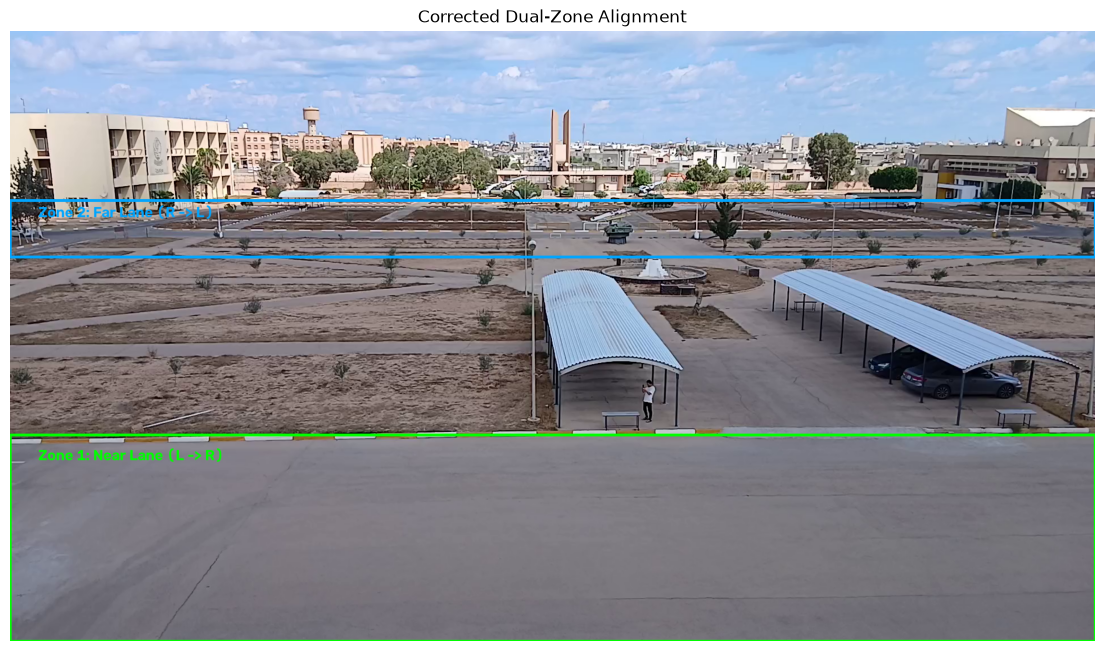

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load frame
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()

# Zone 1: Foreground Road (Left -> Right)
zone1_pts = np.array([
    [0, 715],
    [1920, 715],
    [1920, 1080],
    [0, 1080]
], dtype=np.int32)

# Zone 2: Far Back Road (Right -> Left) - Shifted up to match the far white car path
zone2_pts = np.array([
    [0, 300],
    [1920, 300],
    [1920, 400],
    [0, 400]
], dtype=np.int32)

display = frame.copy()

# Draw polygons
cv2.polylines(display, [zone1_pts], isClosed=True, color=(0, 255, 0), thickness=3)   # Green = Near
cv2.polylines(display, [zone2_pts], isClosed=True, color=(255, 165, 0), thickness=3) # Orange = Far

cv2.putText(display, "Zone 1: Near Lane (L -> R)", (50, 760), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
cv2.putText(display, "Zone 2: Far Lane (R -> L)", (50, 330), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 165, 0), 2)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
plt.title("Corrected Dual-Zone Alignment")
plt.axis("off")
plt.show()

In [12]:
import cv2
import numpy as np
from collections import deque
from ultralytics import YOLO

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
VIDEO_PATH = r"C:\Users\PC-LAB1\img_processing_lab\videos\Bera\Bera5.mp4"
OUTPUT_PATH = "output_dual_zone_speed.mp4"

model = YOLO("visdrone.pt")

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video file: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

# ==========================================
# 2. DUAL-ZONE BOUNDARIES & SCALES
# ==========================================
# Zone 1: Near Lane (Left -> Right)
zone1_pts = np.array([
    [0, 715],
    [1920, 715],
    [1920, 1080],
    [0, 1080]
], dtype=np.int32)
PPM_ZONE1 = 75.0  # ~75 pixels per meter (curb calibrated)

# Zone 2: Far Lane (Right -> Left)
zone2_pts = np.array([
    [0, 300],
    [1920, 300],
    [1920, 400],
    [0, 400]
], dtype=np.int32)
PPM_ZONE2 = 24.0  # ~24 pixels per meter (far perspective)

polygon_z1 = zone1_pts.reshape((-1, 1, 2))
polygon_z2 = zone2_pts.reshape((-1, 1, 2))

# ==========================================
# 3. KALMAN FILTER FOR TRAJECTORY SMOOTHING
# ==========================================
class VelocityKalmanFilter:
    """Smooths 2D position and velocity estimates across frames."""
    def __init__(self, dt=1.0/fps):
        # 4 dynamic params (x, y, vx, vy), 2 measurement params (x, y)
        self.kf = cv2.KalmanFilter(4, 2, type=cv2.CV_32F)
        
        # Explicitly enforce float32 data types across all matrices
        self.kf.measurementMatrix = np.array([[1, 0, 0, 0],
                                              [0, 1, 0, 0]], dtype=np.float32)
        
        self.kf.transitionMatrix = np.array([[1, 0, dt, 0],
                                             [0, 1, 0, dt],
                                             [0, 0, 1, 0],
                                             [0, 0, 0, 1]], dtype=np.float32)
        
        self.kf.processNoiseCov = np.eye(4, dtype=np.float32) * 0.05
        self.kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 0.2
        self.initialized = False

    def update(self, x, y):
        # Enforce float32 explicitly on inputs
        x_val = np.float32(x)
        y_val = np.float32(y)
        measurement = np.array([[x_val], [y_val]], dtype=np.float32)
        
        if not self.initialized:
            self.kf.statePre = np.array([[x_val], [y_val], [0.0], [0.0]], dtype=np.float32)
            self.kf.statePost = np.array([[x_val], [y_val], [0.0], [0.0]], dtype=np.float32)
            self.initialized = True
            return float(x_val), float(y_val)
        
        self.kf.predict()
        corrected = self.kf.correct(measurement)
        return float(corrected[0][0]), float(corrected[1][0])
    
tracking_history = {}
kalman_filters = {}
speed_history = {}

SMOOTHING_WINDOW = int(fps * 0.4)  # ~0.4s temporal window

print("Processing video stream with Dual-Zone Speed Engine...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    current_frame_num = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    
    # Run tracking for motor vehicles
    results = model.track(
        frame, 
        persist=True, 
        imgsz=1280, 
        conf=0.12, 
        classes=[3, 4, 5, 8, 9], 
        verbose=False
    )[0]
    
    if results.boxes is not None and results.boxes.id is not None:
        boxes = results.boxes.xyxy.cpu().numpy()
        track_ids = results.boxes.id.int().cpu().numpy()
        
        for box, track_id in zip(boxes, track_ids):
            x1, y1, x2, y2 = box
            bottom_center = (float((x1 + x2) / 2.0), float(y2))
            
            # Determine which zone the vehicle ground point belongs to
            in_zone1 = cv2.pointPolygonTest(polygon_z1, bottom_center, False) >= 0
            in_zone2 = cv2.pointPolygonTest(polygon_z2, bottom_center, False) >= 0
            
            if not (in_zone1 or in_zone2):
                # Outside active zones - draw dim box and skip speed evaluation
                cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (80, 80, 80), 1)
                continue
            
            # Select zone properties
            pixels_per_meter = PPM_ZONE1 if in_zone1 else PPM_ZONE2
            zone_color = (0, 255, 0) if in_zone1 else (255, 165, 0)
            
            # Initialize Kalman Filter and Tracking History
            if track_id not in kalman_filters:
                kalman_filters[track_id] = VelocityKalmanFilter(dt=1.0/fps)
                tracking_history[track_id] = deque(maxlen=SMOOTHING_WINDOW * 2)
                speed_history[track_id] = deque(maxlen=8)
            
            # Apply Kalman Filtering directly to pixel coordinates
            smooth_x, smooth_y = kalman_filters[track_id].update(bottom_center[0], bottom_center[1])
            tracking_history[track_id].append((smooth_x, smooth_y, current_frame_num))
            
            speed_kmh = 0.0
            if len(tracking_history[track_id]) >= SMOOTHING_WINDOW:
                prev_x, prev_y, prev_frame = tracking_history[track_id][-SMOOTHING_WINDOW]
                
                # Compute Euclidean distance in meters
                dist_px = np.sqrt((smooth_x - prev_x)**2 + (smooth_y - prev_y)**2)
                dist_m = dist_px / pixels_per_meter
                dt = (current_frame_num - prev_frame) / fps
                
                if dt > 0:
                    raw_speed = (dist_m / dt) * 3.6
                    
                    # Filter out non-physical tracking anomalies (> 150 km/h)
                    if raw_speed < 150.0:
                        speed_history[track_id].append(raw_speed)
                    
                    if len(speed_history[track_id]) > 0:
                        speed_kmh = np.mean(speed_history[track_id])
            
            # Draw Bounding Box and Speed Overlay
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), zone_color, 2)
            cv2.circle(frame, (int(smooth_x), int(smooth_y)), 4, (0, 0, 255), -1)
            
            label = f"ID:{track_id} | {speed_kmh:.1f} km/h"
            cv2.putText(frame, label, (int(x1), int(y1) - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, zone_color, 2)

    # Render Active Zone Polygons
    cv2.polylines(frame, [polygon_z1], isClosed=True, color=(0, 255, 0), thickness=2)
    cv2.polylines(frame, [polygon_z2], isClosed=True, color=(255, 165, 0), thickness=2)
    
    out.write(frame)

cap.release()
out.release()
print(f"Done! Processed video saved to '{OUTPUT_PATH}'.")

Processing video stream with Dual-Zone Speed Engine...
Done! Processed video saved to 'output_dual_zone_speed.mp4'.
